In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import warnings

# 忽略警告並設定中文環境
warnings.filterwarnings('ignore')

def set_ch_font():
    system = platform.system()
    if system == "Windows": 
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    elif system == "Darwin": 
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

set_ch_font()
sns.set_theme(style="whitegrid", font=plt.rcParams['font.sans-serif'])

# 1. 精確讀取 01 步驟放在 data/raw 下的資料集
file_path = '../../data/raw/YRBS_2007 2.csv'
df = pd.read_csv(file_path)
print(f"🎉 資料讀取成功！共 {len(df)} 筆數據，包含 {len(df.columns)} 個欄位。")

🎉 資料讀取成功！共 14041 筆數據，包含 103 個欄位。


In [3]:
# 1. 鎖定本次專題核心欄位（含延伸題目要用的性別與年級）
core_cols = ['SeatBeltUse', 'BicyleHelmetUse', 'CurrentAlcoholUse', 'WhatIsYourSex', 'InWhatGradeAreYou']

# 2. 排除核心變數之缺失值並建立副本
df_core = df.dropna(subset=core_cols).copy()

# 3. 強制將欄位轉換為數值型態
for col in core_cols:
    df_core[col] = pd.to_numeric(df_core[col], errors='coerce')
df_core = df_core.dropna().copy()

# 4. 執行 ANOVA 所需的重新編碼 (Recoding)
# 根據 YRBS 定義：1、2 代表很少或從不，3 代表有時，4、5 代表經常或總是
def recode_seatbelt(value):
    if value <= 2: return '高風險組 (很少/從不繫)'
    elif value == 3: return '中風險組 (有時繫)'
    else: return '低風險組 (總是/經常繫)'

df_core['Seatbelt_Group'] = df_core['SeatBeltUse'].apply(recode_seatbelt)

print(f"✅ 核心與延伸欄位清理完畢！可用於統計檢定的有效樣本數：{len(df_core)} 筆")

✅ 核心與延伸欄位清理完畢！可用於統計檢定的有效樣本數：6766 筆


In [25]:
# --- 1. 核心變數：原始編碼頻率表檢查 (符合指引要求的數據診斷) ---
print("【表 2-1：CurrentAlcoholUse 原始頻率表】")
print(df['CurrentAlcoholUse'].value_counts(dropna=False).sort_index())

print("\n【表 2-2：SeatBeltUse 原始頻率表】")
print(df['SeatBeltUse'].value_counts(dropna=False).sort_index())

print("\n【表 2-3：BicyleHelmetUse 原始頻率表】")
print(df['BicyleHelmetUse'].value_counts(dropna=False).sort_index())

# --- 2. 缺失值診斷 ---
print("\n【核心專題變數之缺失值統計】")
missing_report = df[core_cols].isnull().sum()
print(missing_report)

# --- 3. 重編碼後：安全帶風險分組頻率與比例 ---
group_counts = df_core['Seatbelt_Group'].value_counts()
group_props = df_core['Seatbelt_Group'].value_counts(normalize=True)

summary_table_safety = pd.DataFrame({
    '人數 (Counts)': group_counts,
    '比例 (Proportions)': group_props
})
print("\n【表 2-4：安全帶使用行為重編碼分佈表 (用於 ANOVA)】")
print(summary_table_safety)

【表 2-1：CurrentAlcoholUse 原始頻率表】
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
NaN    1372
Name: count, dtype: int64

【表 2-2：SeatBeltUse 原始頻率表】
SeatBeltUse
1.0     527
2.0    1011
3.0    2066
4.0    3823
5.0    6465
NaN     149
Name: count, dtype: int64

【表 2-3：BicyleHelmetUse 原始頻率表】
BicyleHelmetUse
1.0    4821
2.0    6761
3.0     683
4.0     404
5.0     322
6.0     414
NaN     636
Name: count, dtype: int64

【核心專題變數之缺失值統計】
SeatBeltUse           149
BicyleHelmetUse       636
CurrentAlcoholUse    1372
WhatIsYourSex          13
InWhatGradeAreYou      69
dtype: int64

【表 2-4：安全帶使用行為重編碼分佈表 (用於 ANOVA)】
                人數 (Counts)  比例 (Proportions)
Seatbelt_Group                               
低風險組 (總是/經常繫)          5271          0.779042
中風險組 (有時繫)              919          0.135826
高風險組 (很少/從不繫)           576          0.085132


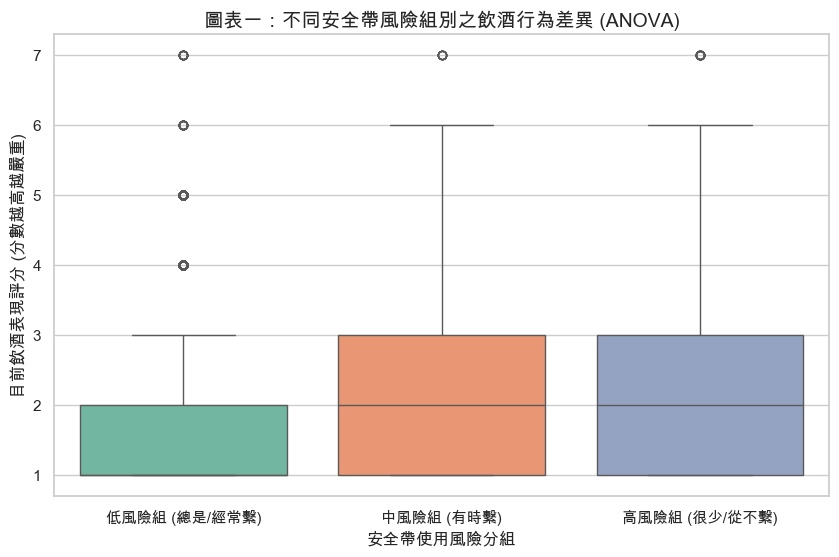

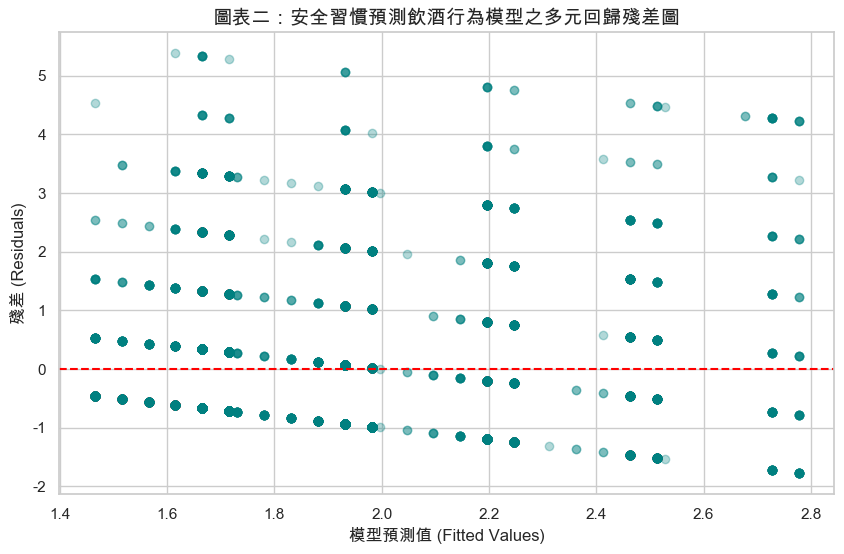

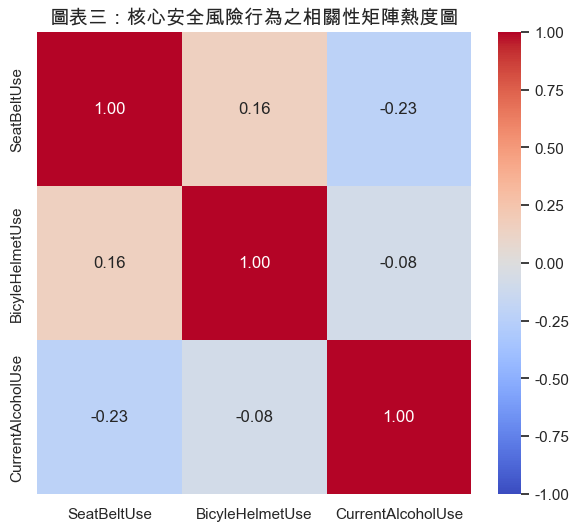

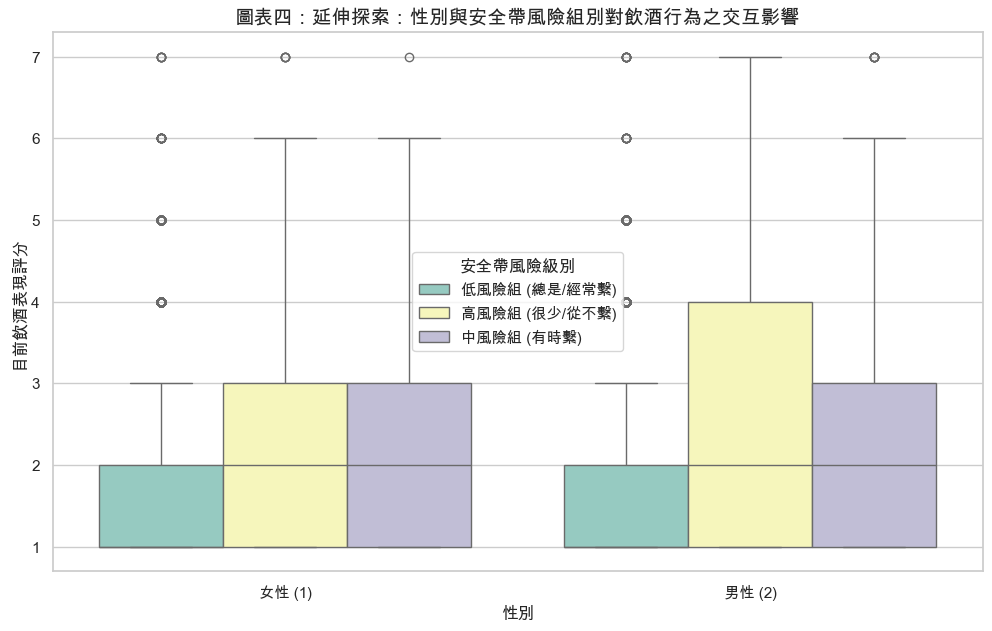

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定畫風與中文字型
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] if platform.system() == "Darwin" else ['Microsoft JhengHei']

# --- 📊 1. ANOVA 盒鬚圖 ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seatbelt_Group', y='CurrentAlcoholUse', data=df_core, palette='Set2', hue='Seatbelt_Group', legend=False)
plt.title('圖表一：不同安全帶風險組別之飲酒行為差異 (ANOVA)', fontsize=14, fontweight='bold')
plt.xlabel('安全帶使用風險分組', fontsize=12)
plt.ylabel('目前飲酒表現評分 (分數越高越嚴重)', fontsize=12)

fig1 = plt.gcf()  # ✨ 關鍵：在 show 之前立刻存入變數 fig1
plt.show()

# --- 📊 2. 回歸分析殘差圖 ---
residuals = model_reg.resid
fitted_values = model_reg.fittedvalues

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.3, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('圖表二：安全習慣預測飲酒行為模型之多元回歸殘差圖', fontsize=14, fontweight='bold')
plt.xlabel('模型預測值 (Fitted Values)', fontsize=12)
plt.ylabel('殘差 (Residuals)', fontsize=12)

fig2 = plt.gcf()  # ✨ 關鍵：在 show 之前立刻存入變數 fig2
plt.show()

# --- 📊 3. 相關性熱度圖 ---
plt.figure(figsize=(7, 6))
corr_matrix = df_core[['SeatBeltUse', 'BicyleHelmetUse', 'CurrentAlcoholUse']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('圖表三：核心安全風險行為之相關性矩陣熱度圖', fontsize=14, fontweight='bold')

fig3 = plt.gcf()  # ✨ 關鍵：在 show 之前立刻存入變數 fig3
plt.show()

# --- 📊 4. 延伸探索：性別、安全帶與酒精交互箱線圖 ---
plt.figure(figsize=(12, 7))
sns.boxplot(x='WhatIsYourSex', y='CurrentAlcoholUse', hue='Seatbelt_Group', data=df_core, palette='Set3')
plt.xticks([0, 1], ['女性 (1)', '男性 (2)'])
plt.title('圖表四：延伸探索：性別與安全帶風險組別對飲酒行為之交互影響', fontsize=14, fontweight='bold')
plt.xlabel('性別', fontsize=12)
plt.ylabel('目前飲酒表現評分', fontsize=12)
plt.legend(title='安全帶風險級別')

fig4 = plt.gcf()  # ✨ 關鍵：在 show 之前立刻存入變數 fig4
plt.show()

=== 🛠️ 執行多元線性回歸分析 (Multiple Linear Regression) ===
                            OLS Regression Results                            
Dep. Variable:      CurrentAlcoholUse   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     141.5
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          2.66e-116
Time:                        01:39:36   Log-Likelihood:                -10838.
No. Observations:                6766   AIC:                         2.169e+04
Df Residuals:                    6761   BIC:                         2.172e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

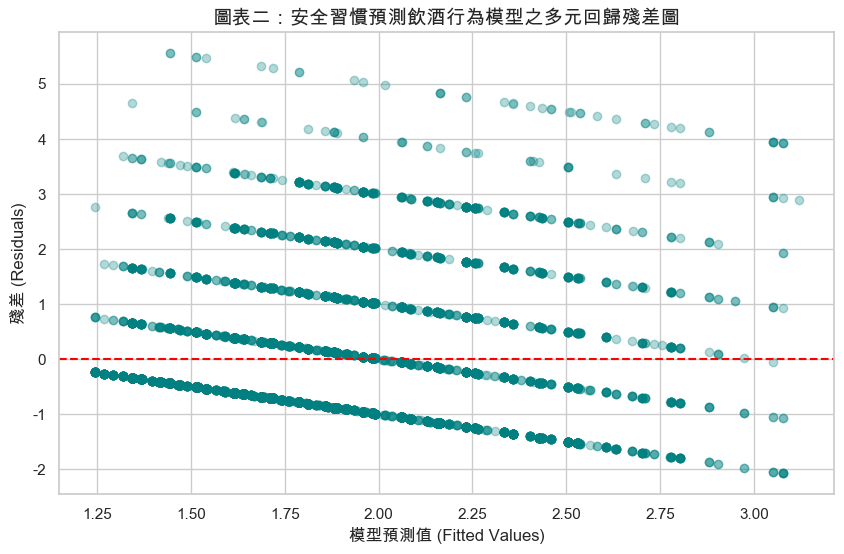

In [27]:
print("=== 🛠️ 執行多元線性回歸分析 (Multiple Linear Regression) ===")
# 將安全防護行為作為核心預測變數，並將性別與年級放入作為控制變數
X = df_core[['SeatBeltUse', 'BicyleHelmetUse', 'WhatIsYourSex', 'InWhatGradeAreYou']]
X = sm.add_constant(X) # 加上常數項截距
Y = df_core['CurrentAlcoholUse']

model_reg = sm.OLS(Y, X).fit()
print(model_reg.summary())

# 繪製圖表：回歸殘差圖
residuals = model_reg.resid
fitted_values = model_reg.fittedvalues

plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.3, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('圖表二：安全習慣預測飲酒行為模型之多元回歸殘差圖', fontsize=14, fontweight='bold')
plt.xlabel('模型預測值 (Fitted Values)', fontsize=12)
plt.ylabel('殘差 (Residuals)', fontsize=12)
fig2 = plt.gcf() # 確保更新後的圖表物件被鎖定
plt.show()

📋 【延伸探索：各性別與年級交叉之安全行為相關性分析】

==================== 女性 (Female) 群體統計 ====================
📍 高一 (9th): 樣本數 n=798 筆
   • 平均飲酒表現: 1.62
   • 安全帶使用平均值: 4.19 | 安全帽使用平均值: 2.20
📍 高二 (10th): 樣本數 n=842 筆
   • 平均飲酒表現: 1.77
   • 安全帶使用平均值: 4.22 | 安全帽使用平均值: 2.00
📍 高三 (11th): 樣本數 n=975 筆
   • 平均飲酒表現: 1.79
   • 安全帶使用平均值: 4.27 | 安全帽使用平均值: 1.81
📍 高四 (12th): 樣本數 n=923 筆
   • 平均飲酒表現: 2.06
   • 安全帶使用平均值: 4.33 | 安全帽使用平均值: 1.64

==================== 男性 (Male) 群體統計 ====================
📍 高一 (9th): 樣本數 n=750 筆
   • 平均飲酒表現: 1.64
   • 安全帶使用平均值: 4.06 | 安全帽使用平均值: 2.28
📍 高二 (10th): 樣本數 n=785 筆
   • 平均飲酒表現: 1.87
   • 安全帶使用平均值: 4.07 | 安全帽使用平均值: 2.15
📍 高三 (11th): 樣本數 n=815 筆
   • 平均飲酒表現: 2.02
   • 安全帶使用平均值: 4.12 | 安全帽使用平均值: 1.99
📍 高四 (12th): 樣本數 n=875 筆
   • 平均飲酒表現: 2.25
   • 安全帶使用平均值: 4.12 | 安全帽使用平均值: 1.81


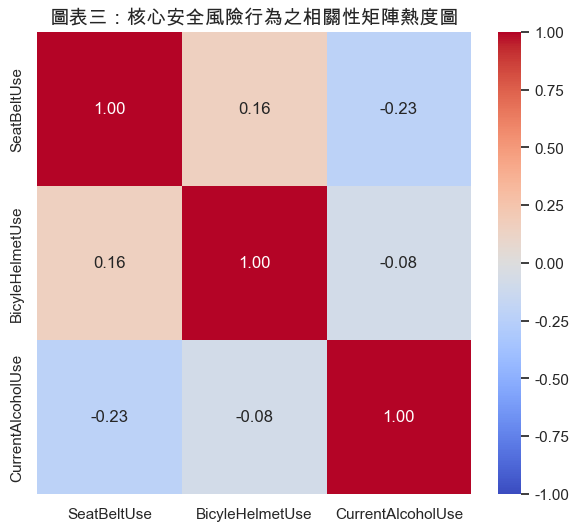

In [11]:
print("📋 【延伸探索：各性別與年級交叉之安全行為相關性分析】")

gender_labels = {1: "女性 (Female)", 2: "男性 (Male)"}
grade_labels = {1: "高一 (9th)", 2: "高二 (10th)", 3: "高三 (11th)", 4: "高四 (12th)"}

# 循環輸出不同子群體的描述性統計
for g_val, g_name in gender_labels.items():
    print(f"\n==================== {g_name} 群體統計 ====================")
    for grd_val, grd_name in grade_labels.items():
        subset = df_core[(df_core['WhatIsYourSex'] == g_val) & (df_core['InWhatGradeAreYou'] == grd_val)]
        if len(subset) > 0:
            print(f"📍 {grd_name}: 樣本數 n={len(subset)} 筆")
            print(f"   • 平均飲酒表現: {subset['CurrentAlcoholUse'].mean():.2f}")
            print(f"   • 安全帶使用平均值: {subset['SeatBeltUse'].mean():.2f} | 安全帽使用平均值: {subset['BicyleHelmetUse'].mean():.2f}")

# 繪製圖表：相關性矩陣熱度圖 (展示冒險集群的關聯強度)
fig_corr_heatmap = plt.figure(figsize=(7, 6))
corr_matrix = df_core[['SeatBeltUse', 'BicyleHelmetUse', 'CurrentAlcoholUse']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('圖表三：核心安全風險行為之相關性矩陣熱度圖', fontsize=14, fontweight='bold')
plt.show()

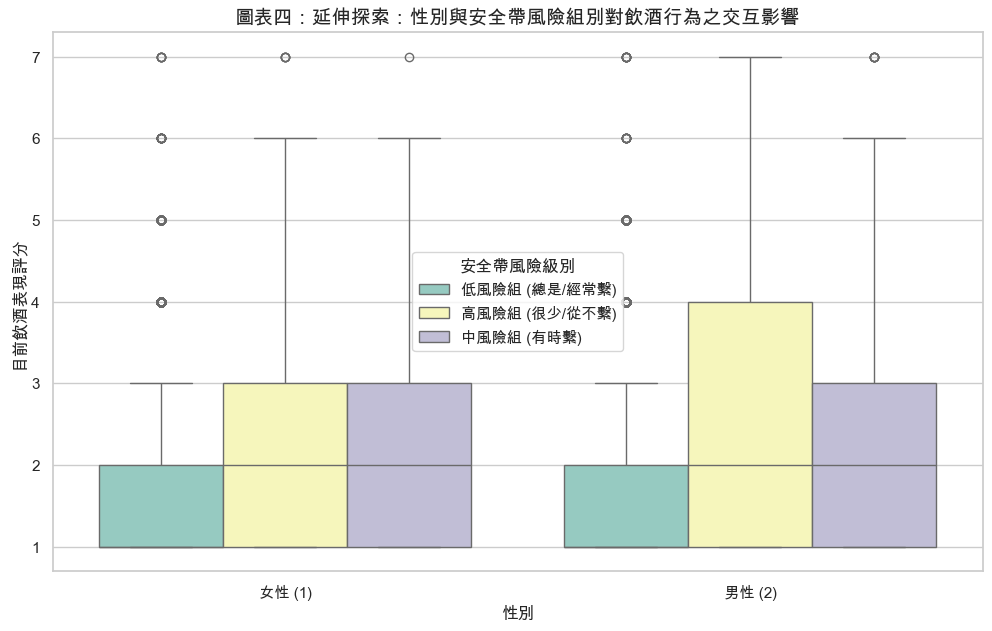

In [13]:
# 繪製圖表：性別、安全帶風險組別與酒精使用的多因子探索箱線圖
fig_extension_box = plt.figure(figsize=(12, 7))

sns.boxplot(
    x='WhatIsYourSex', 
    y='CurrentAlcoholUse', 
    hue='Seatbelt_Group', 
    data=df_core, 
    palette='Set3'
)

plt.xticks([0, 1], ['女性 (1)', '男性 (2)'])
plt.title('圖表四：延伸探索：性別與安全帶風險組別對飲酒行為之交互影響', fontsize=14, fontweight='bold')
plt.xlabel('性別', fontsize=12)
plt.ylabel('目前飲酒表現評分', fontsize=12)
plt.legend(title='安全帶風險級別')
plt.show()

In [29]:
import os

# 1. 建立專案規範的所有必要目錄
os.makedirs('../../outputs/tables/', exist_ok=True)
os.makedirs('../../outputs/figures/', exist_ok=True)
os.makedirs('../../data/processed/', exist_ok=True)

# 2. 儲存統計表格 (Tables)
summary_table_safety.to_csv('../../outputs/tables/02_safety_group_summary.csv')
group_stats.to_csv('../../outputs/tables/02_anova_descriptive_stats.csv')

# 將回歸係數表也導出為 CSV，方便你在做一頁式報告時複製數據
regression_results = pd.DataFrame({
    'Coefficient': model_reg.params,
    'P-Value': model_reg.pvalues,
    'Std.Error': model_reg.bse
})
regression_results.to_csv('../../outputs/tables/02_regression_summary_table.csv')
print("📊 1. 統計結果分析表格（包含ANOVA與回歸表）已存入：../../outputs/tables/")

# 3. 儲存視覺化圖表 (Figures)
save_fig_dir = '../../outputs/figures/'
fig1.savefig(os.path.join(save_fig_dir, '02_anova_seatbelt_box.png'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(save_fig_dir, '02_regression_residual.png'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(save_fig_dir, '02_safety_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
fig4.savefig(os.path.join(save_fig_dir, '02_gender_safety_extension_box.png'), dpi=300, bbox_inches='tight')
print(f"🖼️  2. 四張高階專題圖表已成功存入：{save_fig_dir}")

# 4. 儲存最終分析資料檔
df_core.to_csv('../../data/processed/yrbs_final.csv', index=False, encoding='utf-8-sig')
print("🚀 3. 安全心理學最終分析資料集已存入：../../data/processed/yrbs_final.csv")
print("\n🎉 【全套專題統計分析與檔案儲存已全面圓滿成功！】")

📊 1. 統計結果分析表格（包含ANOVA與回歸表）已存入：../../outputs/tables/
🖼️  2. 四張高階專題圖表已成功存入：../../outputs/figures/
🚀 3. 安全心理學最終分析資料集已存入：../../data/processed/yrbs_final.csv

🎉 【全套專題統計分析與檔案儲存已全面圓滿成功！】
